
# Atlas notebooks
--------------
----------
## Calculation and hatching of the uncertainty in projected delta changes.

*08/07/2021*

**M. Iturbide** (Santander Meteorology Group. Institute of Physics of Cantabria, CSIC-UC, Santander, Spain).

> This notebook is a simple example of uncertainty visualization in projected delta changes. Example data available at [auxiliary-material](https://github.com/IPCC-WG1/Atlas/tree/master/notebooks/auxiliary-material) is used. The advanced method for the uncertainty visualization of the Atlas Chapter and the Interactive Atlas is included in [04_map_figures.R](https://github.com/IPCC-WG1/Atlas/tree/master/datasets-interactive-atlas/04_map_figures.R). Additionally, the basic hatching R-functions are defined in [hatching-functions.R](https://github.com/IPCC-WG1/Atlas/tree/master/datasets-interactive-atlas/hatching-functions/hatching-functions.R)

> This and other notebooks are available at https://github.com/IPCC-WG1/Atlas for reproducibility and reusability purpose. In particular, [load-remote-data_R.ipynb](https://github.com/IPCC-WG1/Atlas/tree/master/notebooks/load-remote-data_R.ipynb) describes the generation of the example data used in this notebook.


### 1. Load libraries, functions and data

**Libraries**:

In [12]:
# Climate4R package for data loading
library(loadeR)
# Climate4R package for data visualization
# <https://doi.org/10.1016/j.envsoft.2017.09.008>
library(visualizeR)

**Functions**: Here an additional function is used, `agreement` for the simplest measure of uncertainty. To load the function in the working environment use the `source` R base function as follows.

In [11]:
# Load functions for computing uncertainty (signal, signal.ens and agreement)
source("../datasets-interactive-atlas/hatching-functions/hatching-functions.R")

**data**: The data used in this example is available under the auxiliary-material folder. The `load-remote-data_R.ipynb` notebook shows how they were generated.

In [13]:
hist <- loadGridData("auxiliary-material/CMIP5_historical_pr.nc", var = "pr")
ssp <- loadGridData("auxiliary-material/CMIP5_rcp85_pr.nc", var = "pr")

[2021-07-08 16:28:13] Defining geo-location parameters

[2021-07-08 16:28:13] Defining time selection parameters

[2021-07-08 16:28:13] Retrieving data subset ...

[2021-07-08 16:28:13] Done

[2021-07-08 16:28:13] Defining geo-location parameters

[2021-07-08 16:28:13] Defining time selection parameters

[2021-07-08 16:28:13] Retrieving data subset ...

[2021-07-08 16:28:13] Done



### 2. Parameter setting 

**Set the parameters** of the different functions used in this notebook.

In [37]:
# Color key graphical parameter:
  # n = min value
  # m = max value
  # s = cut value frequency
  # ct = Brewer color code (see 'RColorBrewer::display.brewer.all()')
m <- 50
n <- -50
s <- 5
ct <- "BrBG"
revc <- FALSE

### 3. Calculate delta change and the associated uncertainty

Deltas are the arithmetic difference between future and historical time slices. Relative delta is also calculated using the multi-model mean 


In [19]:
# Calculate delta
delta <- gridArithmetics(climatology(ssp), climatology(hist), operator = "-")
# Calculate the ensemble mean
delta.ens <- aggregateGrid(delta, aggr.mem = list(FUN = mean, na.rm = T))
hist.ens <- aggregateGrid(climatology(hist), aggr.mem = list(FUN = mean, na.rm = T))
# Calculate relative delta
rel.delta <- gridArithmetics(delta.ens, 
                             hist.ens, 
                             100, 
                             operator = c("/", "*"))

[2021-07-08 16:36:36] - Computing climatology...

[2021-07-08 16:36:36] - Done.

[2021-07-08 16:36:36] - Computing climatology...

[2021-07-08 16:36:36] - Done.

[2021-07-08 16:36:36] - Aggregating members...

[2021-07-08 16:36:36] - Done.

[2021-07-08 16:36:36] - Computing climatology...

[2021-07-08 16:36:36] - Done.

[2021-07-08 16:36:36] - Aggregating members...

[2021-07-08 16:36:36] - Done.



Check the output with a first visualization:

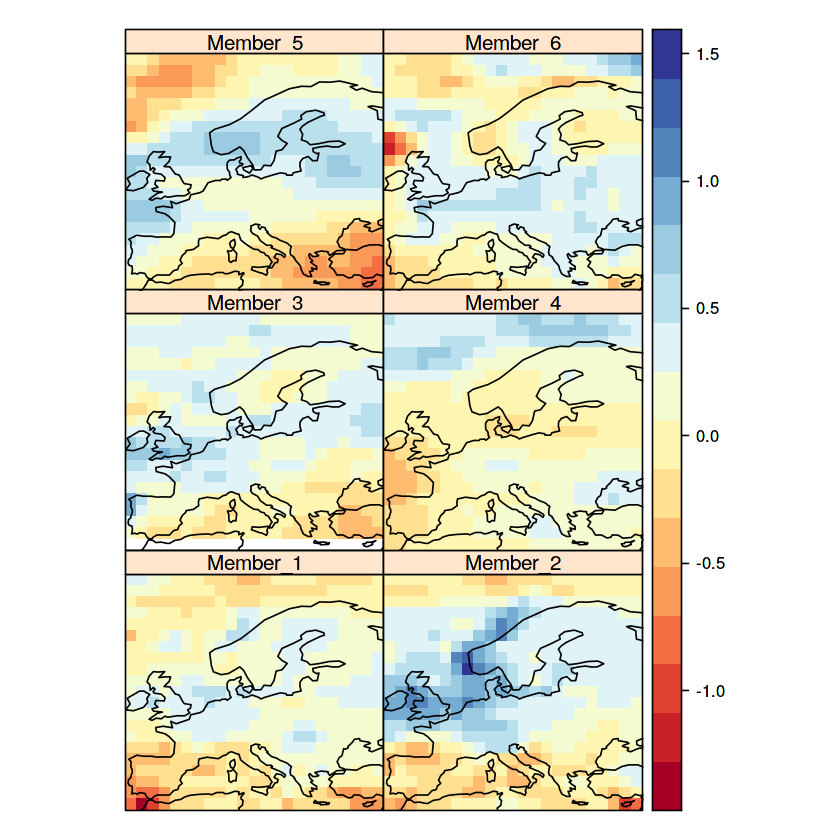

In [17]:
spatialPlot(delta, backdrop.theme = "coastline")

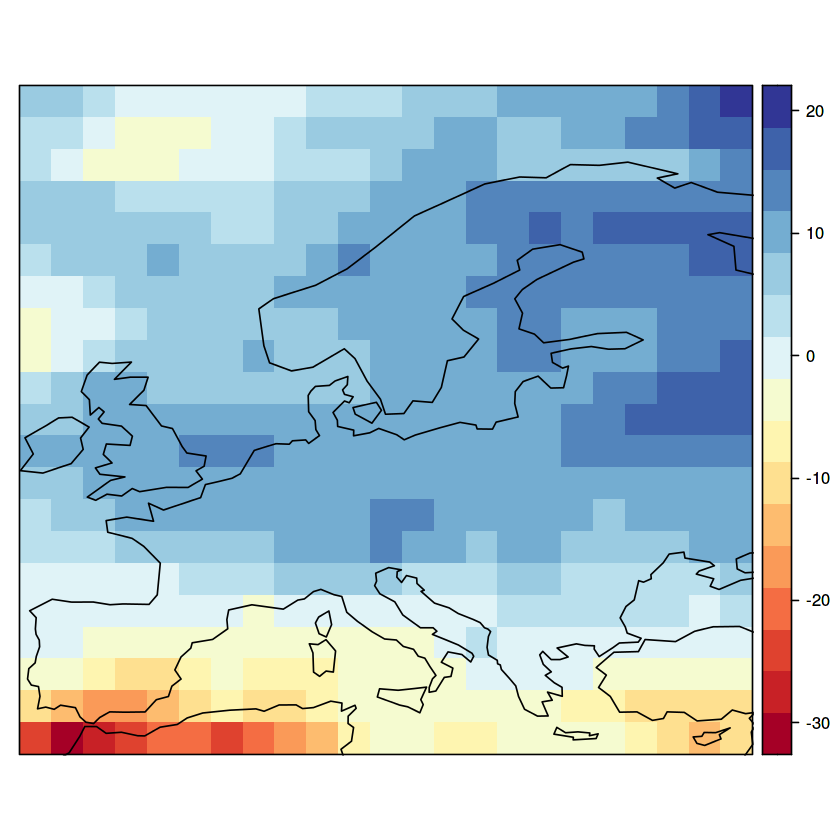

In [18]:
spatialPlot(rel.delta, backdrop.theme = "coastline")

Calculate the uncertainty and check visually:

[2021-07-08 16:37:55] - Aggregating members...

[2021-07-08 16:37:55] - Done.



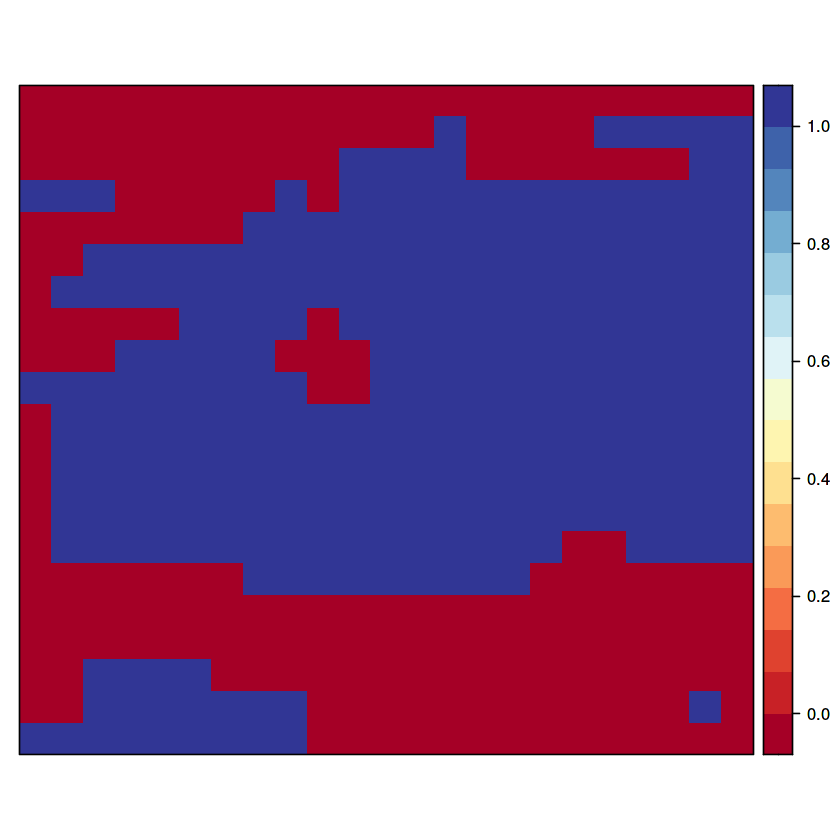

In [21]:
uncer <- aggregateGrid(delta, aggr.mem = list(FUN = agreement, th = 80))
spatialPlot(uncer)

Create the spatial object of the hatches and check visually:

[2021-07-08 16:39:48] - Computing climatology...

[2021-07-08 16:39:49] - Done.



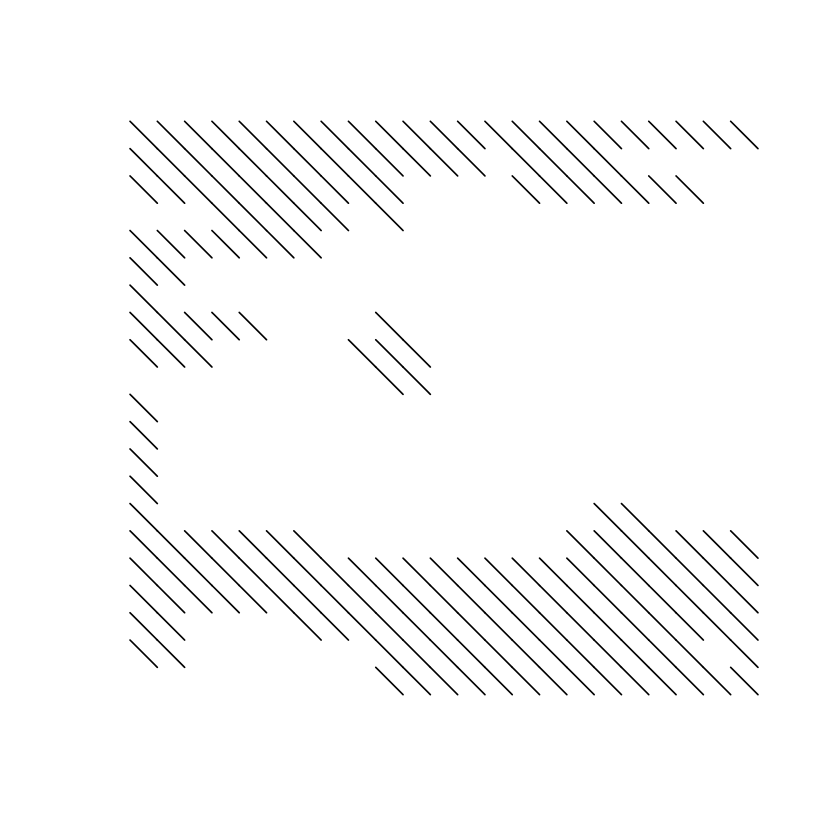

In [25]:
uncer.hatch <- map.hatching(clim = climatology(uncer), threshold = "0.5", angle = "-45",
                             condition = "LT", density = 1,  lwd = 0.6,
                             upscaling.aggr.fun = list(FUN = mean))
plot(uncer.hatch[[2]])

### 4. Generate map figure

Select what to plot in the final figure:

In [39]:
#  Use the relative delta...
out <- rel.delta
# ... or calculate the ensemble mean of the absolute delta by uncommenting the following line
# out <- aggregateGrid(delta, aggr.mem = list(FUN = mean))

Produce the final figure (the hatches are passed to argument `sp.layout`:

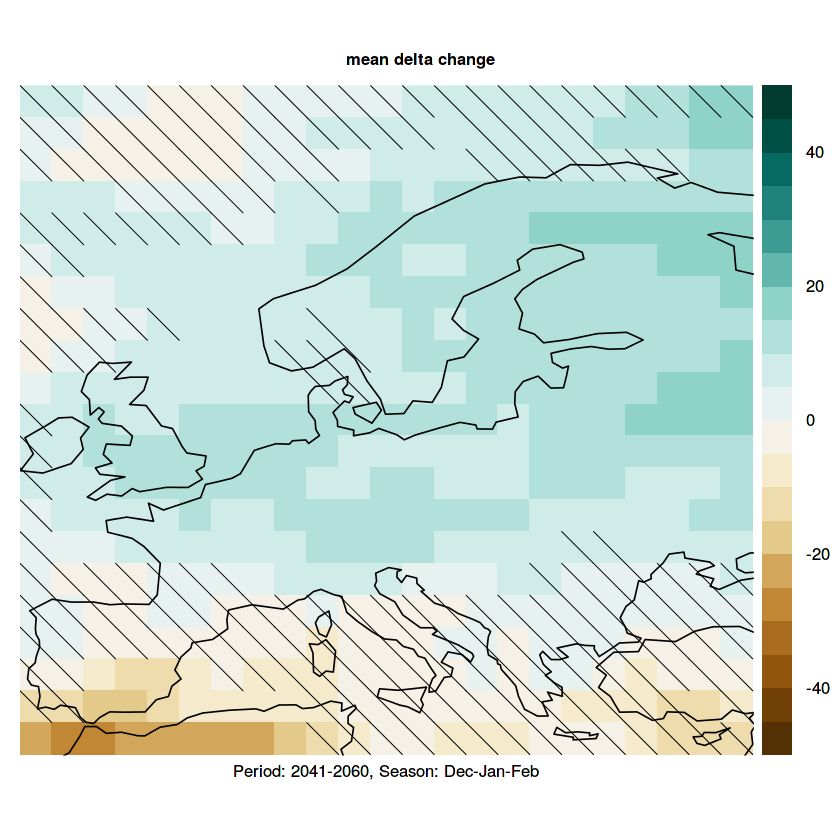

In [38]:
pl <- spatialPlot(out, 
            color.theme = ct, 
            rev.colors = revc, 
            at = seq(n, m, s), 
            set.max = m, set.min = n,
            backdrop.theme = "coastline",
            main = list("mean delta change", cex = 0.8),
            xlab = list(paste0("Period: ", paste(range(future.period), collapse = "-"), ", Season: ", paste(month.abb[season], collapse = "-")), cex = 0.8),
            sp.layout = list(uncer.hatch),
            par.settings = list(axis.line = list(col = 'transparent')))
pl

### 5. Session Information

In [ ]:
sessionInfo()